# Real World Classification

## Load data

Import the necessary libraries

In [ ]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
#!unzip data.zip

Archive:  data.zip
   creating: data/
   creating: data/linear_data/
  inflating: data/linear_data/linear_data_A.npz  
  inflating: data/linear_data/linear_data_B.npz  
  inflating: data/linear_data/linear_data_C.npz  
  inflating: data/linear_data/linear_data_D.npz  
   creating: data/logistic_data/
  inflating: data/logistic_data/logistic_data_A.npz  
  inflating: data/logistic_data/logistic_data_B.npz  
  inflating: data/logistic_data/logistic_data_C.npz  
  inflating: data/logistic_data/logistic_data_D.npz  
  inflating: data/NYCU_Iris.csv      
   creating: model/
  inflating: model/activations.py    
  inflating: model/gradients.py      
  inflating: model/linear_model.py   
  inflating: model/metrics.py        
  inflating: model/utils.py          
   creating: model/__pycache__/
  inflating: model/__pycache__/metrics.cpython-310.pyc  


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [3]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [4]:
# 找出有缺失值的欄位
missing_cols = df.columns[df.isnull().any()]

# 轉成數值（避免字串問題）
for col in df.columns:
    if col not in ['Id', 'Species']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 各欄位分別計算
print("=== Before Imputation ===")
for col in missing_cols:
    median = df[col].median()
    std = df[col].std()

# 計算 median 和 std
stats = pd.DataFrame({
    'median': df[missing_cols].median(),
    'std': df[missing_cols].std()
})

stats


=== Before Imputation ===


,median,std
SepalLengthCm,6.300000,1.037115
SepalWidthCm,2.900000,0.389564
PetalLengthCm,5.085612,1.582807
PetalWidthCm,1.600000,0.706689
BranchLength,16.300000,1.035228


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=5)  # 你也可以調整 k 值
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- --------------------- ----------

    return df, feature_cols

df, feature_cols = data_preprocessing(df)


df_miss = df[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm","BranchLength"]]
stats_after = pd.DataFrame({
    'median': df_miss.median(),
    'std': df_miss.std()
})

print("=== After Imputation ===")
stats_after

=== After Imputation ===


,median,std
SepalLengthCm,6.300000,1.009275
SepalWidthCm,2.900000,0.372434
PetalLengthCm,5.035683,1.514955
PetalWidthCm,1.700000,0.694645
BranchLength,16.300000,1.011012


In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

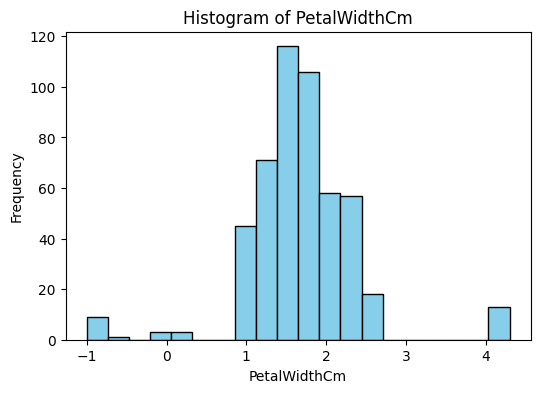

In [7]:
from sklearn.feature_selection import r_regression
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,4))

# 畫 histogram（改顏色）
plt.hist(df["PetalWidthCm"], bins=20, color='skyblue', edgecolor='black')

# 標籤
plt.xlabel("PetalWidthCm")
plt.ylabel("Frequency")
plt.title("Histogram of PetalWidthCm")

plt.show()

In [8]:

features = df.select_dtypes(include=[np.number]).columns.tolist()

exclude = ["PetalWidthCm", "Id", 'Species']
features = [f for f in features if f not in exclude]

X = df[features]
y = df["PetalWidthCm"]

# 計算 Pearson correlation
corr = r_regression(X, y)

corr_df = pd.DataFrame({
    "feature": features,
    "correlation": corr
}).sort_values(by="correlation", ascending=False)


In [9]:
neg_corr_df = corr_df.sort_values(by="correlation")
top_positive = neg_corr_df.tail(1)
top5_negative = neg_corr_df.head(5)
print("Feature with largest positive correlation:")
print(top_positive)
print()
print("Top 5 negative correlations:")
print(top5_negative)

Feature with largest positive correlation:
                  feature  correlation
26  PetalWidthCompactness      0.99167

Top 5 negative correlations:
                  feature  correlation
11    SepalWidthMajorAxis    -0.096350
46        SepalGlossIndex    -0.095200
14  SepalWidthCompactness    -0.088496
16    SepalWidthCurvature    -0.081334
12    SepalWidthMinorAxis    -0.074392


['PetalWidthCompactness', 'SepalWidthMajorAxis', 'SepalGlossIndex', 'SepalWidthCompactness', 'SepalWidthCurvature', 'SepalWidthMinorAxis']


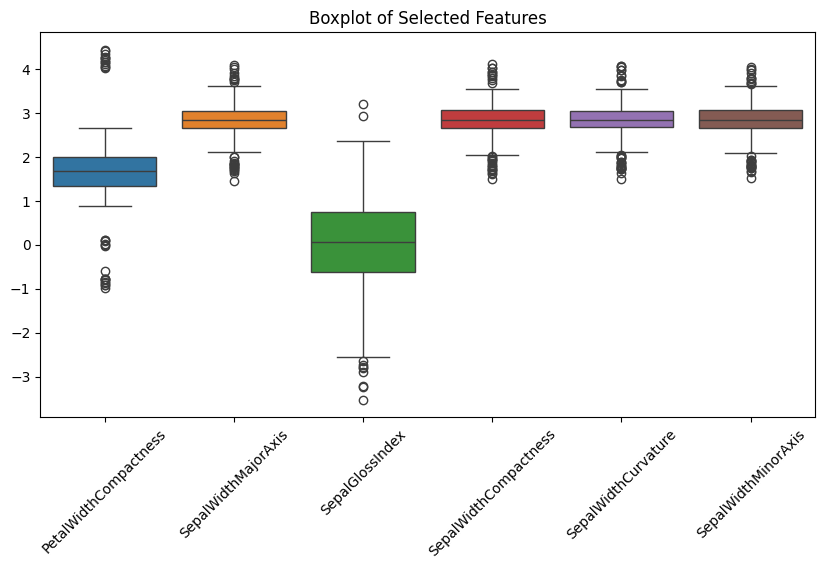

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

max_pos_feature = top_positive["feature"].values[0]

selected_features = [max_pos_feature] + top5_negative["feature"].tolist()

print(selected_features)

plt.figure(figsize=(10,5))
sns.boxplot(data=df[selected_features])

plt.title("Boxplot of Selected Features")
plt.xticks(rotation=45)
plt.show()

## Model Training

### Prepare the data

In [11]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

np.random.seed(seed)
# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)



In [12]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


# K-fold Cross-Validation

### Train the model!

In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

# =========================================================
# 基本設定
# =========================================================
seed = 40
np.random.seed(seed)

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

kf = KFold(n_splits=5, shuffle=True, random_state=40)

# 建立 4x4 結果表
results = pd.DataFrame(index=reg_lambdas, columns=learning_rates)


all_fold_scores = {}  # (reg_lambda, lr) -> [fold1, ..., fold5]

for reg_lambda in reg_lambdas:
    for lr in learning_rates:
        model = LinearModel(
            dim=X_train.shape[1],
            is_reg=False,
            loss_fn=loss_fn,
            grad_fn=grad_fn,
            act_fn=act_fn,
            lr=lr,
            reg_type='l2',
            reg_lambda=reg_lambda,
            n_iteration=10000,
            random_state=40,
            verbose=False,
            plot_curve=False
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv= KFold(n_splits=5, shuffle=True, random_state=40),
            scoring='accuracy'
        )

        all_fold_scores[(reg_lambda, lr)] = scores
        results.loc[reg_lambda, lr] = scores.mean()

results = results.astype(float)
results.index.name = "reg_lambda"
results.columns.name = "learning_rate"

print("Average accuracy over 5 folds:")
print(results.round(10))

Average accuracy over 5 folds:
learning_rate     0.005     0.010     0.100     0.500
reg_lambda                                           
1.0            0.717143  0.722857  0.722857  0.722857
2.0            0.720000  0.728571  0.725714  0.691429
4.0            0.725714  0.725714  0.725714  0.534286
8.0            0.722857  0.717143  0.717143  0.465714


lr = 0.01, reg_lambda = 2.0
Testing results:
Model Evaluation
Accuracy  : 0.7600
Precision : 0.7381
Recall    : 0.8158
F1-score  : 0.7750


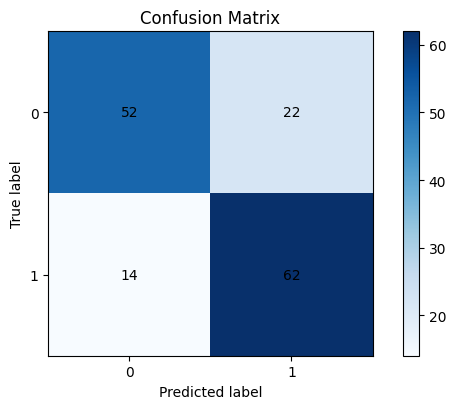

lr = 0.005, reg_lambda = 4.0
Testing results:
Model Evaluation
Accuracy  : 0.7533
Precision : 0.7241
Recall    : 0.8289
F1-score  : 0.7730


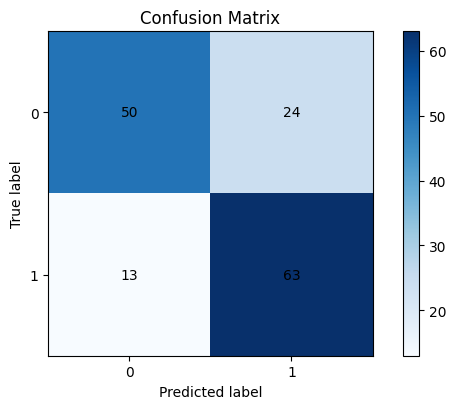

lr = 0.01, reg_lambda = 4.0
Testing results:
Model Evaluation
Accuracy  : 0.7400
Precision : 0.7176
Recall    : 0.8026
F1-score  : 0.7578


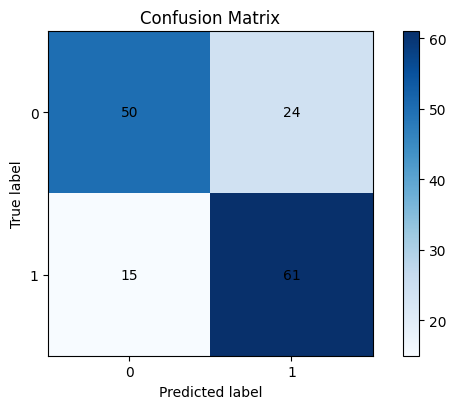

lr = 0.1, reg_lambda = 2.0
Testing results:
Model Evaluation
Accuracy  : 0.7533
Precision : 0.7294
Recall    : 0.8158
F1-score  : 0.7702


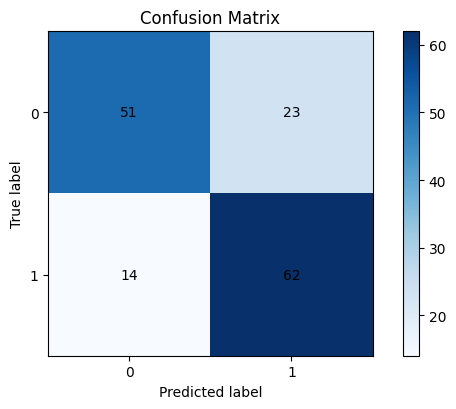

lr = 0.1, reg_lambda = 4.0
Testing results:
Model Evaluation
Accuracy  : 0.7400
Precision : 0.7176
Recall    : 0.8026
F1-score  : 0.7578


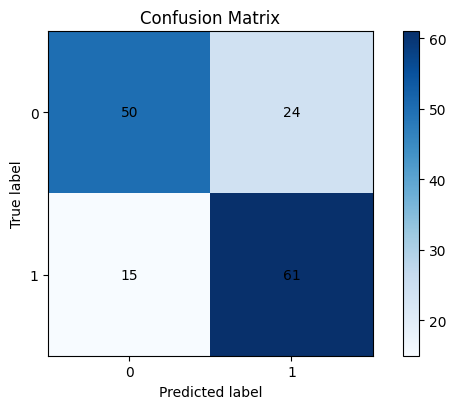

In [14]:
top_settings = [
    {"lr": 0.01, "reg_lambda": 2.0}, #top one
    {"lr": 0.005,  "reg_lambda": 4.0}, # The second-highest 4 settings
    {"lr": 0.01,  "reg_lambda": 4.0},
    {"lr": 0.1,  "reg_lambda": 2.0},
    {"lr": 0.1,  "reg_lambda": 4.0},
]

from model.metrics import evaluate_binary_classifier

for i, setting in enumerate(top_settings, 1):
    print("="*60)
    print(f"lr = {setting['lr']}, reg_lambda = {setting['reg_lambda']}")

    model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=logloss,
        grad_fn=logloss_sigmoid_grad,
        act_fn=sigmoid,
        lr=setting["lr"],
        reg_type='l2',
        reg_lambda=setting["reg_lambda"],
        n_iteration=10000,
        random_state=40,
        verbose=False,
        plot_curve=False
    )

    model.fit(X_train, y_train)

    y_test_pred = model.predict(X_test)

    print("Testing results:")
    evaluate_binary_classifier(y_test, y_test_pred)